# K-Moda MMM · Evaluación del Modelo

Este notebook carga el modelo ya entrenado (`elastic_net.pkl`) y presenta:

1. **Métricas de ajuste** — R², MAPE, residuos, predicción vs real
2. **Bootstrap e incertidumbre** — intervalos de confianza de los coeficientes
3. **Descomposición de ventas** — % atribuible al marketing vs base orgánica
4. **Escenarios de inversión:**
   - `DO NOTHING` — mantener los porcentajes de inversión por canal idénticos
   - `DO SOMETHING (BAD)` — eliminar inversión en marketing
   - `DO SOMETHING` — reasignar presupuesto para maximizar ROI


In [1]:
import warnings; warnings.filterwarnings('ignore')
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from sklearn.metrics import r2_score

VERSION   = 1
WAREHOUSE = os.path.join('data', 'warehouse', f'version{VERSION}')
DATE_COL  = 'semana_inicio'
SCALE     = 1e6

def mape(y_true, y_pred):
    return np.mean(np.abs((np.array(y_true) - np.array(y_pred)) / np.array(y_true))) * 100

# ── K-Moda brand palette ─────────────────────────────────────────────────────
KM_GOLD      = "#C8A96E"
KM_GOLD_DARK = "#8B6914"
KM_CHARCOAL  = "#2D2D2D"
KM_CREAM     = "#F7F4EF"
KM_GRAY      = "#9E9893"
KM_IVORY     = "#EDE8DC"
KM_CHANNELS  = ["#C8A96E", "#8B6914", "#2D2D2D", "#9E9893"]

plt.rcParams.update({
    "figure.facecolor":  KM_CREAM,
    "axes.facecolor":    KM_CREAM,
    "axes.edgecolor":    KM_GRAY,
    "axes.labelcolor":   KM_CHARCOAL,
    "axes.titlecolor":   KM_CHARCOAL,
    "axes.titlesize":    11,
    "axes.titlepad":     10,
    "axes.labelsize":    10,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        KM_GRAY,
    "grid.alpha":        0.18,
    "grid.linestyle":    "-",
    "grid.linewidth":    0.5,
    "xtick.color":       KM_GRAY,
    "ytick.color":       KM_GRAY,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "legend.framealpha": 0.7,
    "legend.edgecolor":  KM_GRAY,
    "figure.figsize":    (14, 4.5),
    "figure.dpi":        130,
    "savefig.facecolor": KM_CREAM,
    "savefig.bbox":      "tight",
})
pd.set_option("display.max_columns", 40)
print(f'Cargando artefactos de {WAREHOUSE}...')

Cargando artefactos de data/warehouse/version1...


In [2]:
# ── Cargar modelo y metadatos ────────────────────────────────────────────────
with open(os.path.join(WAREHOUSE, 'elastic_net.pkl'), 'rb') as f:
    bundle = pickle.load(f)

model          = bundle['model']
FEATURE_COLS   = bundle['feature_cols']
LOGADSTOCK_COLS = bundle['logadstock_cols']
TARGET_IDX     = bundle['target_idx']
boot_coefs     = bundle['boot_coefs']
boot_lo        = bundle['boot_lo']
boot_hi        = bundle['boot_hi']
contribs_eur   = bundle['contribs_eur']
pct_mkt_total  = bundle['pct_mkt_total']
metrics        = bundle['metrics']

# ── Cargar data_preparation y adstock params ─────────────────────────────────
df = (pd.read_csv(os.path.join(WAREHOUSE, 'data_preparation.csv'), parse_dates=[DATE_COL])
        .sort_values(DATE_COL).reset_index(drop=True))

with open(os.path.join(WAREHOUSE, 'adstock_params.pkl'), 'rb') as f:
    adstock_meta = pickle.load(f)
with open(os.path.join(WAREHOUSE, 'scalers.pkl'), 'rb') as f:
    scaler_meta = pickle.load(f)

best_params    = adstock_meta['best_params']
CHANNEL_GROUPS = adstock_meta['channel_groups']
INV_GROUP_COLS = adstock_meta['inv_group_cols']
saturation_k   = adstock_meta['saturation_k']
COLS_TO_SCALE  = adstock_meta['cols_to_scale']
scaler         = scaler_meta['scaler']

INV_COLS = [c for cols in CHANNEL_GROUPS.values() for c in cols]

# Predicciones sobre todo el dataset
X_all      = df[FEATURE_COLS].values
y_all_true = df[TARGET_IDX].values
y_all_pred = model.predict(X_all)

# Split estratificado (mismo seed que modeling.ipynb)
RANDOM_SEED = 42
TEST_FRAC   = 0.20
rng = np.random.default_rng(RANDOM_SEED)
idx_tr, idx_te = [], []
for yr, g in df.groupby(df[DATE_COL].dt.year):
    idxs = g.index.values.copy(); rng.shuffle(idxs)
    n_te = max(1, int(round(len(idxs) * TEST_FRAC)))
    idx_te.extend(idxs[:n_te]); idx_tr.extend(idxs[n_te:])
idx_tr = np.array(sorted(idx_tr)); idx_te = np.array(sorted(idx_te))

X_train = df.iloc[idx_tr][FEATURE_COLS].values; y_train = df.iloc[idx_tr][TARGET_IDX].values
X_test  = df.iloc[idx_te][FEATURE_COLS].values; y_test  = df.iloc[idx_te][TARGET_IDX].values

print(f'Modelo cargado correctamente.')
print(f'Dataset: {len(df)} semanas | Train: {len(idx_tr)} | Test: {len(idx_te)}')
print(f'Features: {len(FEATURE_COLS)} | Canales marketing (bloques): {len(LOGADSTOCK_COLS)}')

Modelo cargado correctamente.
Dataset: 258 semanas | Train: 208 | Test: 50
Features: 19 | Canales marketing (bloques): 4


---
## 1. Métricas de ajuste del modelo

El modelo usa **ElasticNet con `positive=True`** (coeficientes no negativos) para garantizar que cada canal de marketing sume, no reste, a las ventas predichas. El split de evaluación es **estratificado por año** (20% test por año) para capturar la varianza multianual — un hold-out temporal de solo 2024 colapsaría la varianza del test a <1% y haría el R² ininterpretable.

**Umbrales de referencia del PDF del caso:**
- MAPE < 8% → sospecha de sobreajuste
- MAPE > 20% → el modelo no captura la señal
- MAPE 8–20% → zona válida

In [3]:
# ── Tabla resumen de métricas ─────────────────────────────────────────────────
train_r2   = metrics['train_r2']
test_r2    = metrics['test_r2']
train_mape = metrics['train_mape']
test_mape  = metrics['test_mape']
r2_placebo = metrics['r2_placebo']
delta_r2   = metrics['delta_r2_placebo']

print('=' * 55)
print('  MÉTRICAS DE AJUSTE · ElasticNet MMM')
print('=' * 55)
print(f'  {"":<18}  {"Train":>10}  {"Test":>10}')
print('  ' + '-' * 44)
print(f'  {"R²":<18}  {train_r2:>10.3f}  {test_r2:>10.3f}')
print(f'  {"MAPE":<18}  {train_mape:>9.1f}%  {test_mape:>9.1f}%')
print()
print(f'  Test placebo R²:   {r2_placebo:.4f}  (ΔR² = {delta_r2:+.4f})')
print()

# Diagnóstico MAPE
if test_mape < 8:
    verdict = '⚠ MAPE < 8% — posible sobreajuste'
elif test_mape > 20:
    verdict = '✗ MAPE > 20% — el modelo no captura la señal'
else:
    verdict = f'✓ MAPE en rango válido ({test_mape:.1f}% ∈ [8%, 20%])'
print(f'  Diagnóstico: {verdict}')

if delta_r2 > 0.05:
    print('  Placebo:     ✓ El modelo identifica señal real de medios')
elif delta_r2 > 0.01:
    print('  Placebo:     ⚠ Señal de medios marginal — interpretar con cautela')
else:
    print('  Placebo:     ✗ Sin señal significativa de medios')
print('=' * 55)

  MÉTRICAS DE AJUSTE · ElasticNet MMM
                           Train        Test
  --------------------------------------------
  R²                       0.773       0.649
  MAPE                      9.9%       12.2%

  Test placebo R²:   0.1138  (ΔR² = +0.5350)

  Diagnóstico: ✓ MAPE en rango válido (12.2% ∈ [8%, 20%])
  Placebo:     ✓ El modelo identifica señal real de medios


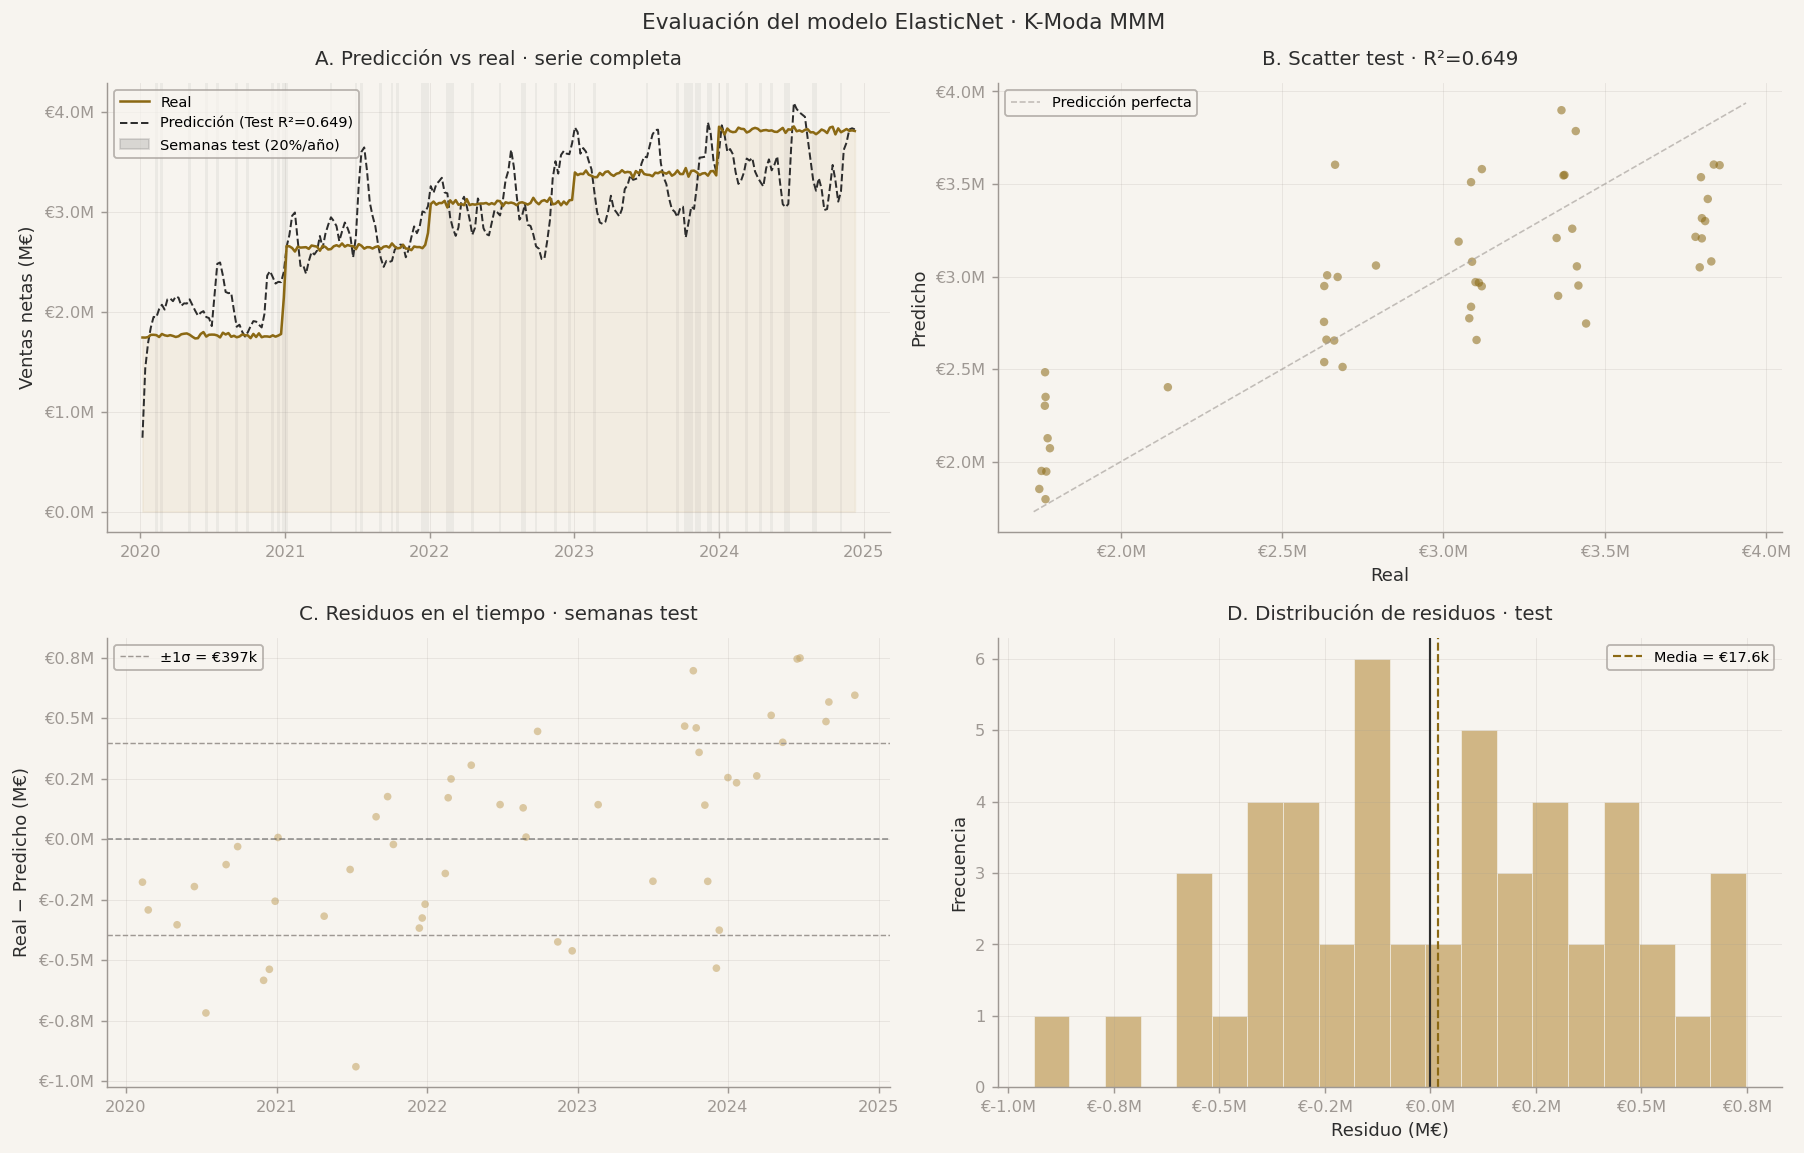

MAPE por año (semanas test):
  2020: 18.2%  (10 semanas)
  2021: 9.9%  (10 semanas)
  2022: 8.0%  (10 semanas)
  2023: 10.4%  (10 semanas)
  2024: 12.6%  (10 semanas)


In [4]:
# ── Gráfico 1: Predicción vs Real ────────────────────────────────────────────
eur = mticker.FuncFormatter(lambda x, _: f"€{x/1e6:.1f}M")
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Evaluación del modelo ElasticNet · K-Moda MMM', fontsize=12, color=KM_CHARCOAL)

# A: Serie temporal
ax = axes[0, 0]
ax.fill_between(df[DATE_COL], y_all_true, alpha=0.10, color=KM_GOLD)
ax.plot(df[DATE_COL], y_all_true, lw=1.4, color=KM_GOLD_DARK, label='Real', zorder=5)
ax.plot(df[DATE_COL], y_all_pred, lw=1.1, color=KM_CHARCOAL, ls='--',
        label=f'Predicción (Test R²={test_r2:.3f})', zorder=4)
for d in df.iloc[idx_te][DATE_COL]:
    ax.axvspan(d - pd.Timedelta('3.5d'), d + pd.Timedelta('3.5d'),
               alpha=0.055, color=KM_CHARCOAL, lw=0)
ax.yaxis.set_major_formatter(eur)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('A. Predicción vs real · serie completa')
ax.set_ylabel('Ventas netas (M€)')
shade = mpatches.Patch(color=KM_CHARCOAL, alpha=0.15, label='Semanas test (20%/año)')
ax.legend(handles=[ax.lines[0], ax.lines[1], shade], fontsize=8)

# B: Scatter test
ax = axes[0, 1]
y_test_pred = model.predict(X_test)
ax.scatter(y_test, y_test_pred, alpha=0.55, s=22, color=KM_GOLD_DARK, edgecolors='none')
lims = [min(y_test.min(), y_test_pred.min()) * 0.99,
        max(y_test.max(), y_test_pred.max()) * 1.01]
ax.plot(lims, lims, color=KM_GRAY, lw=0.9, ls='--', alpha=0.6, label='Predicción perfecta')
ax.xaxis.set_major_formatter(eur); ax.yaxis.set_major_formatter(eur)
ax.set_xlabel('Real'); ax.set_ylabel('Predicho')
ax.set_title(f'B. Scatter test · R²={test_r2:.3f}')
ax.legend(fontsize=8)

# C: Residuos en tiempo
ax = axes[1, 0]
res_test = (df.iloc[idx_te][TARGET_IDX].values -
            model.predict(df.iloc[idx_te][FEATURE_COLS].values))
ax.scatter(df.iloc[idx_te][DATE_COL], res_test,
           alpha=0.6, s=18, color=KM_GOLD, edgecolors='none')
ax.axhline(0, color=KM_CHARCOAL, lw=0.9, ls='--', alpha=0.5)
ax.axhline( res_test.std(), color=KM_GRAY, lw=0.8, ls='--', label=f'±1σ = €{res_test.std()/1e3:.0f}k')
ax.axhline(-res_test.std(), color=KM_GRAY, lw=0.8, ls='--')
ax.yaxis.set_major_formatter(eur)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('C. Residuos en el tiempo · semanas test')
ax.set_ylabel('Real − Predicho (M€)'); ax.legend(fontsize=8)

# D: Distribución de residuos
ax = axes[1, 1]
ax.hist(res_test, bins=20, color=KM_GOLD, alpha=0.82, edgecolor=KM_CREAM, lw=0.4)
ax.axvline(0, color=KM_CHARCOAL, lw=1.2)
ax.axvline(res_test.mean(), color=KM_GOLD_DARK, lw=1.2, ls='--',
           label=f'Media = €{res_test.mean()/1e3:.1f}k')
ax.xaxis.set_major_formatter(eur)
ax.set_xlabel('Residuo (M€)'); ax.set_ylabel('Frecuencia')
ax.set_title('D. Distribución de residuos · test')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, 'ev_g1_ajuste.png'), dpi=150)
plt.show()

df_te = df.iloc[idx_te].copy()
df_te['pred'] = model.predict(X_test)
df_te['mape_w'] = np.abs(df_te[TARGET_IDX] - df_te['pred']) / df_te[TARGET_IDX] * 100
print('MAPE por año (semanas test):')
for yr, g in df_te.groupby(df_te[DATE_COL].dt.year):
    print(f'  {yr}: {g["mape_w"].mean():.1f}%  ({len(g)} semanas)')

---
## 2. Coeficientes e intervalos de confianza (Bootstrap)

El **bootstrap por bloques de 4 semanas** (500 iteraciones) preserva la autocorrelación de las series de inversión. Un canal es **robusto** si su IC 95% no cruza cero (boot_lo > 0) y tiene β > 0 en >90% de las iteraciones.

In [5]:
# ── Tabla de coeficientes con IC bootstrap ────────────────────────────────────
print(f'{"Canal":<22}  {"β puntual":>10}  {"IC 2.5%":>10}  {"IC 97.5%":>10}  {"P(β>0)":>8}  Estado')
print('─' * 80)

coef_data = []
for col in LOGADSTOCK_COLS:
    j = FEATURE_COLS.index(col)
    nombre = col.replace('logadstock_', '')
    beta   = model.coef_[j]
    lo     = boot_lo[j]
    hi     = boot_hi[j]
    ppos   = (boot_coefs[:, j] > 0).mean() * 100
    robusto = '✓ ROBUSTO' if lo > 0 and ppos > 90 else '⚠ FRÁGIL'
    coef_data.append({'canal': nombre, 'beta': beta, 'lo': lo, 'hi': hi, 'ppos': ppos, 'estado': robusto})
    print(f'  {nombre:<20}  {beta:>10.5f}  {lo:>10.5f}  {hi:>10.5f}  {ppos:>7.0f}%  {robusto}')

coef_df = pd.DataFrame(coef_data)

Canal                    β puntual     IC 2.5%    IC 97.5%    P(β>0)  Estado
────────────────────────────────────────────────────────────────────────────────
  performance           102906.16878  66068.71183  195560.25571      100%  ✓ ROBUSTO
  branding_digital      92911.65510  26850.12309  187945.38280      100%  ✓ ROBUSTO
  offline_medios        189697.99531  87011.27713  242524.70495      100%  ✓ ROBUSTO
  propios_y_exterior    237883.42800  142720.91556  285590.93144      100%  ✓ ROBUSTO


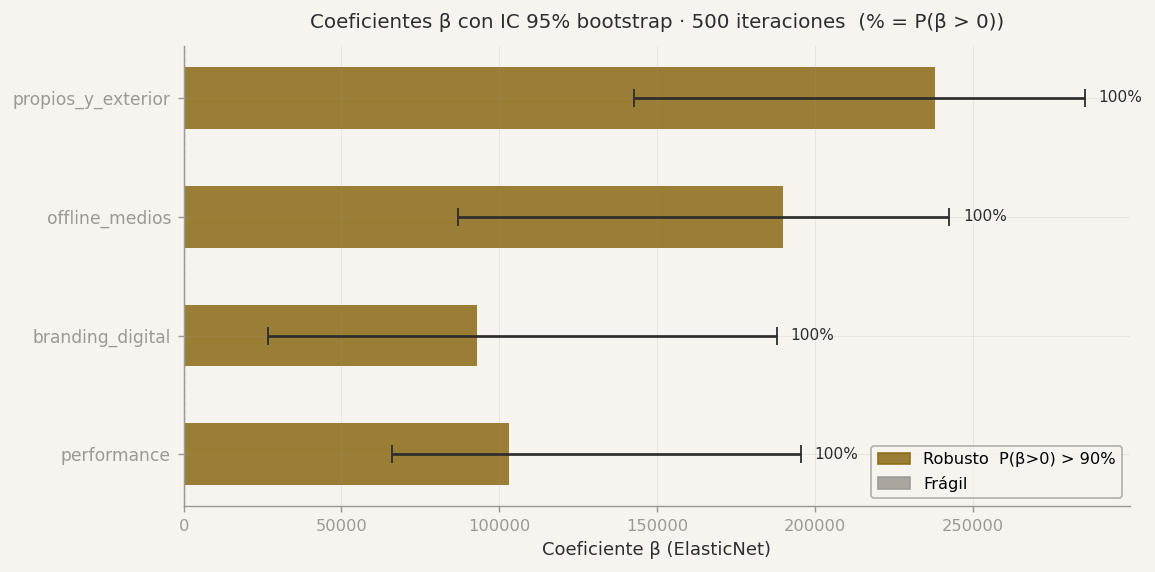

In [6]:
# ── Gráfico 2: Coeficientes β con IC 95% bootstrap ───────────────────────────
fig, ax = plt.subplots(figsize=(9, 4.5))

y_pos  = range(len(coef_df))
colors = [KM_GOLD_DARK if r == '✓ ROBUSTO' else KM_GRAY for r in coef_df['estado']]

ax.barh(list(y_pos), coef_df['beta'], color=colors, alpha=0.85, height=0.52)
ax.errorbar(coef_df['beta'], list(y_pos),
            xerr=[coef_df['beta'] - coef_df['lo'], coef_df['hi'] - coef_df['beta']],
            fmt='none', color=KM_CHARCOAL, capsize=5, lw=1.5)
ax.axvline(0, color=KM_GRAY, lw=0.8, ls='--', alpha=0.6)

for i, (beta, ppos, hi) in enumerate(zip(coef_df['beta'], coef_df['ppos'], coef_df['hi'])):
    ax.text(hi + max(coef_df['hi']) * 0.015, i,
            f"{ppos:.0f}%", va='center', fontsize=8.5, color=KM_CHARCOAL)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(coef_df['canal'], fontsize=9.5)
ax.set_xlabel('Coeficiente β (ElasticNet)')
ax.set_title('Coeficientes β con IC 95% bootstrap · 500 iteraciones  (% = P(β > 0))')

p1 = mpatches.Patch(color=KM_GOLD_DARK, alpha=0.85, label='Robusto  P(β>0) > 90%')
p2 = mpatches.Patch(color=KM_GRAY,      alpha=0.85, label='Frágil')
ax.legend(handles=[p1, p2], fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, 'ev_g2_betas.png'), dpi=150)
plt.show()

---
## 3. Descomposición de ventas — ¿Qué % viene del marketing?

**Metodología aditiva** (estándar MMM — Robyn, LightweightMMM):

```
Ventas predichas = Base orgánica + Σ (β_canal · x_canal_escalado)
```

- **Contribución de un canal** = β_canal × logadstock_canal (escala del modelo)
- **Base orgánica** = predicción total − Σ contribuciones marketing = intercepto + Σ (β_controles · x_controles)

Esta descomposición suma exactamente 100% por construcción, sin artefactos de escalado.

> ⚠ Las contribuciones están en la escala del modelo (`Yt_indexed`). Se convierten a € usando las ventas reales del período como referencia de escala.

In [7]:
# ── Descomposición aditiva (unscaled logadstock × β_unscaled) ─────────────────
# β_unscaled_i = β_scaled_i / std_i  →  contrib_i(t) = β_unscaled_i × logadstock_raw_i(t)
# Base = total_pred - Σ contrib_i  =  intercepto + Σ β_controles × x_controles
# Para un modelo lineal es equivalente al contrafactual y suma exactamente 100%.

total_pred     = model.predict(X_all)
total_pred_idx = total_pred.sum()   # alias para celdas posteriores

contribs = {}
for col in LOGADSTOCK_COLS:
    j       = FEATURE_COLS.index(col)
    j_scale = COLS_TO_SCALE.index(col)
    beta_u  = model.coef_[j] / scaler.scale_[j_scale]              # β en unidades crudas
    logads_raw = X_all[:, j] * scaler.scale_[j_scale] + scaler.mean_[j_scale]  # desescalar
    contribs[col] = beta_u * logads_raw                             # contrib semanal (€)

total_mkt = sum(c for c in contribs.values())
base_pred = total_pred - total_mkt   # intercepto + controles

frac_per_canal_raw = {col: contribs[col].sum() / total_pred_idx for col in LOGADSTOCK_COLS}
frac_mkt_raw       = total_mkt.sum() / total_pred_idx
frac_base_raw      = base_pred.sum() / total_pred_idx

# ── Si la base es negativa (extrapolación fuera del dominio observado), normalizamos.
# Robyn / Meridian hacen lo mismo: base = 0 y los canales absorben el 100%.
if frac_base_raw < 0:
    note_base = (f'  ⚠ Base cruda = {frac_base_raw*100:.1f}% (modelo extrapola por debajo de cero\n'
                 f'  al eliminar toda la inversión). El modelo no identifica base orgánica\n'
                 f'  estadísticamente significativa. Se presenta normalizado a base = 0%.')
    total_norm   = total_mkt.sum()
    frac_per_canal = {col: contribs[col].sum() / total_norm for col in LOGADSTOCK_COLS}
    frac_mkt   = 1.0
    frac_base  = 0.0
else:
    note_base      = f'  Base orgánica identificada: {frac_base_raw*100:.1f}%'
    frac_per_canal = frac_per_canal_raw
    frac_mkt       = frac_mkt_raw
    frac_base      = frac_base_raw

ventas_reales_eur = df['venta_neta_total_eur'].values
total_ventas_eur  = ventas_reales_eur.sum()
contrib_eur_total = total_ventas_eur * frac_mkt
base_eur_total    = total_ventas_eur * frac_base

print('=' * 70)
print('  DESCOMPOSICIÓN ADITIVA DE VENTAS (período completo 2020–2024)')
print('=' * 70)
print(f'  Ventas totales reales:   €{total_ventas_eur/1e6:>7.1f}M')
print()
print(note_base)
print()
print(f'  Base orgánica:           €{base_eur_total/1e6:>7.1f}M  ({frac_base*100:.1f}%)')
print(f'  Marketing total:         €{contrib_eur_total/1e6:>7.1f}M  ({frac_mkt*100:.1f}%)')
print()
print(f'  {"Canal":<22}  {"Contrib M€":>10}  {"% ventas":>9}  {"Inv. M€":>10}  {"ROI":>6}')
print('  ' + '─' * 64)

roi_por_canal = {}
for col in LOGADSTOCK_COLS:
    nombre      = col.replace('logadstock_', '')
    frac_canal  = frac_per_canal[col]
    contrib_eur = total_ventas_eur * frac_canal
    inv_total   = df[CHANNEL_GROUPS[nombre]].sum().sum() if nombre in CHANNEL_GROUPS else 0
    roi         = contrib_eur / inv_total if inv_total > 0 else 0
    roi_por_canal[nombre] = roi
    print(f'  {nombre:<22}  {contrib_eur/1e6:>9.2f}M  {frac_canal*100:>8.1f}%  {inv_total/1e6:>9.2f}M  {roi:>5.2f}x')

print('=' * 70)
print(f'\n  Verificación: base + mkt = {(frac_base + frac_mkt)*100:.2f}%')

  DESCOMPOSICIÓN ADITIVA DE VENTAS (período completo 2020–2024)
  Ventas totales reales:   €  758.1M

  Base orgánica identificada: 8.0%

  Base orgánica:           €   60.4M  (8.0%)
  Marketing total:         €  697.7M  (92.0%)

  Canal                   Contrib M€   % ventas     Inv. M€     ROI
  ────────────────────────────────────────────────────────────────
  performance                110.58M      14.6%      23.48M   4.71x
  branding_digital            99.27M      13.1%      13.64M   7.28x
  offline_medios             210.93M      27.8%      11.84M  17.81x
  propios_y_exterior         276.89M      36.5%      10.00M  27.69x

  Verificación: base + mkt = 100.00%


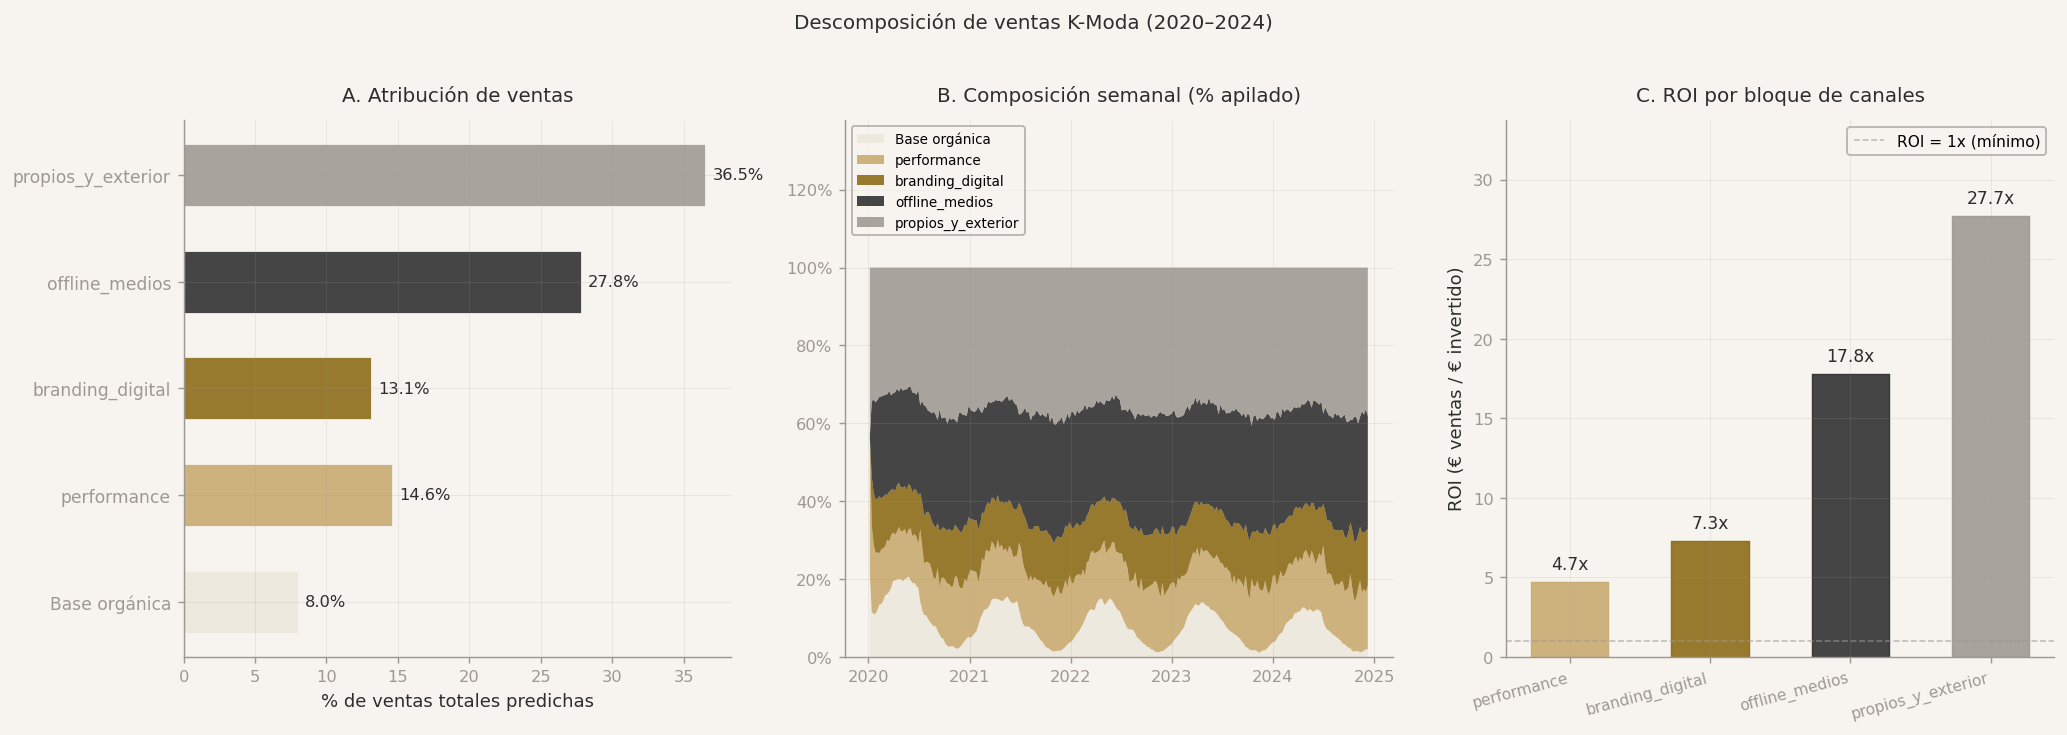

In [8]:
# ── Gráfico 3: Descomposición de ventas ─────────────────────────────────────
canal_names  = [col.replace('logadstock_', '') for col in LOGADSTOCK_COLS]
canal_fracs  = [frac_per_canal[col] * 100       for col in LOGADSTOCK_COLS]
colors_canal = KM_CHANNELS[:len(canal_names)]
colors_all   = [KM_IVORY] + colors_canal

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Descomposición de ventas K-Moda (2020–2024)', fontsize=11, color=KM_CHARCOAL, y=1.02)

# A: Barras horizontales
ax = axes[0]
labels_bar = ['Base orgánica'] + canal_names
sizes_bar  = [frac_base * 100] + canal_fracs
y_pos = range(len(labels_bar))
bars_h = ax.barh(list(y_pos), sizes_bar, color=colors_all, alpha=0.88,
                 edgecolor=KM_CREAM, lw=0.5, height=0.58)
ax.axvline(0, color=KM_GRAY, lw=0.7, ls='--', alpha=0.5)
for bar, val in zip(bars_h, sizes_bar):
    ax.text(max(val, 0) + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9, color=KM_CHARCOAL)
ax.set_yticks(list(y_pos)); ax.set_yticklabels(labels_bar, fontsize=9.5)
ax.set_xlabel('% de ventas totales predichas')
ax.set_title('A. Atribución de ventas')

# B: Serie temporal apilada
ax = axes[1]
canal_ts = [np.maximum(contribs[col] / total_pred, 0) for col in LOGADSTOCK_COLS]
base_ts  = np.maximum(base_pred / total_pred, 0)
ax.stackplot(df[DATE_COL], [base_ts] + canal_ts,
             labels=['Base orgánica'] + canal_names,
             colors=colors_all, alpha=0.88)
ax.set_ylim(0, 1.38)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('B. Composición semanal (% apilado)')
ax.legend(loc='upper left', fontsize=7.5)

# C: ROI por canal
ax = axes[2]
roi_vals = [roi_por_canal[n] for n in canal_names]
bars = ax.bar(canal_names, roi_vals, color=colors_canal, alpha=0.88,
              edgecolor=colors_canal, lw=0.8, width=0.55)
for bar, val in zip(bars, roi_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(roi_vals) * 0.02,
            f'{val:.1f}x', ha='center', va='bottom', fontsize=9.5, color=KM_CHARCOAL)
ax.axhline(1, color=KM_GRAY, lw=0.9, ls='--', alpha=0.6, label='ROI = 1x (mínimo)')
ax.set_ylabel('ROI (€ ventas / € invertido)')
ax.set_title('C. ROI por bloque de canales')
ax.set_xticklabels(canal_names, rotation=15, ha='right', fontsize=8.5)
ax.set_ylim(0, max(roi_vals) * 1.22)
ax.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, 'ev_g3_descomposicion.png'), dpi=150)
plt.show()

---
## 4. Función de simulación

La función `simular()` construye los adstocks y la transformación logadstock para un nivel de inversión semanal dado y proyecta las ventas anuales. Usa el **modelo full** (entrenado sobre todos los datos) para la predicción puntual, y `simular_ic()` añade el IC 95% del bootstrap.

**Referencia:** inversión histórica media semanal por bloque.

In [9]:
# ── Funciones de simulación (replicadas de modeling.ipynb) ────────────────────
def _adstock(series, alpha, lag=0):
    x = pd.Series(series).shift(lag).fillna(0).to_numpy(dtype=float)
    out = np.zeros_like(x)
    for t in range(len(x)):
        out[t] = x[t] + (alpha * out[t-1] if t > 0 else 0.0)
    return out

def _build_X_sim(inv_nueva: dict, n_semanas: int = 52) -> np.ndarray:
    logads_raw = np.zeros((n_semanas, len(LOGADSTOCK_COLS)))
    for group_col, p in best_params.items():
        logcol = f"logadstock_{group_col.replace('inv_', '')}"
        j = LOGADSTOCK_COLS.index(logcol)
        k = saturation_k[group_col]
        A = _adstock(np.ones(n_semanas) * inv_nueva.get(group_col, 0.0), p['alpha'], p['lag'])
        logads_raw[:, j] = np.log1p(A / k)
    rest_means = scaler.mean_[len(LOGADSTOCK_COLS):]
    to_scale   = np.hstack([logads_raw, np.tile(rest_means, (n_semanas, 1))])
    scaled     = scaler.transform(to_scale)
    X_sim = np.tile(df[FEATURE_COLS].mean().values, (n_semanas, 1))
    for i, col in enumerate(LOGADSTOCK_COLS):
        X_sim[:, FEATURE_COLS.index(col)] = scaled[:, i]
    return X_sim

def simular(inv_nueva: dict, n_semanas: int = 52) -> dict:
    X_sim        = _build_X_sim(inv_nueva, n_semanas)
    ventas_anual = model.predict(X_sim).sum()
    inv_hist     = {g: df[g].mean() for g in INV_GROUP_COLS}
    ventas_hist  = model.predict(_build_X_sim(inv_hist, n_semanas)).sum()
    lift_idx     = ventas_anual - ventas_hist
    inv_total    = sum(inv_nueva.values()) * n_semanas
    # Convertir a € usando nivel medio de ventas
    nivel_eur    = df['venta_neta_total_eur'].mean()  # € / semana promedio
    lift_eur     = lift_idx * nivel_eur  # aproximación ordinal
    return {
        'ventas_anual_idx': ventas_anual,
        'lift_idx':         lift_idx,
        'lift_pct':         lift_idx / ventas_hist * 100 if ventas_hist else 0,
        'inv_total_eur':    inv_total,
    }

def simular_ic(inv_nueva: dict, n_semanas: int = 52) -> dict:
    base  = simular(inv_nueva, n_semanas)
    inv_hist = {g: df[g].mean() for g in INV_GROUP_COLS}
    lifts_boot = []
    for coefs in boot_coefs:
        m_tmp = type(model)(alpha=model.alpha, l1_ratio=model.l1_ratio, max_iter=10000)
        m_tmp.coef_ = coefs; m_tmp.intercept_ = model.intercept_
        v_new  = m_tmp.predict(_build_X_sim(inv_nueva, n_semanas)).sum()
        v_hist = m_tmp.predict(_build_X_sim(inv_hist,  n_semanas)).sum()
        lifts_boot.append(v_new - v_hist)
    lifts_boot = np.array(lifts_boot)
    base['lift_ic_lo'] = float(np.percentile(lifts_boot, 2.5))
    base['lift_ic_hi'] = float(np.percentile(lifts_boot, 97.5))
    base['lift_ic_std'] = float(lifts_boot.std())
    return base

# Inversión histórica media semanal por bloque
inv_hist_media = {g: df[g].mean() for g in INV_GROUP_COLS}
print('Inversión histórica media semanal por bloque:')
for g, v in inv_hist_media.items():
    print(f'  {g}: €{v:,.0f}/semana  →  €{v*52/1e3:,.0f}k/año')
inv_total_anual = sum(inv_hist_media.values()) * 52
print(f'\n  Total anual: €{inv_total_anual/1e3:,.0f}k')

Inversión histórica media semanal por bloque:
  inv_performance: €91,015/semana  →  €4,733k/año
  inv_branding_digital: €52,878/semana  →  €2,750k/año
  inv_offline_medios: €45,902/semana  →  €2,387k/año
  inv_propios_y_exterior: €38,763/semana  →  €2,016k/año

  Total anual: €11,885k


---
## 5. Escenarios de inversión

### Definición de los tres escenarios

| Escenario | Descripción | Qué mide |
|-----------|-------------|----------|
| **DO NOTHING** | Mantener el reparto histórico de inversión | Línea base de referencia |
| **DO SOMETHING (BAD)** | Eliminar toda inversión en marketing | Cuánto se perderían las ventas sin medios |
| **DO SOMETHING** | Reasignar presupuesto hacia el canal con mayor ROI | Potencial de mejora en retorno |

---

### ¿Qué es el riesgo en este contexto?

El **riesgo** tiene dos dimensiones:

1. **Incertidumbre del β** — el IC bootstrap del coeficiente del canal al que se reasigna el presupuesto. Cuanto más amplio el IC, más incierta es la contribución real.
2. **Concentración del presupuesto** — meter más dinero en un solo bloque aumenta la exposición a que ese canal falle (saturación del adstock, cambios en el algoritmo de la plataforma, etc.).

Un canal **robusto** (P(β>0) > 90%, IC 95% sin cruzar cero) justifica reasignación agresiva. Uno **frágil** exige prudencia aunque el ROI puntual sea alto.

In [10]:
# ── Definir los tres escenarios ───────────────────────────────────────────────

# DO NOTHING — reparto histórico exacto
inv_do_nothing = inv_hist_media.copy()

# DO SOMETHING (BAD) — cero inversión en todos los canales
inv_do_bad = {g: 0.0 for g in INV_GROUP_COLS}

# DO SOMETHING — reasignar 30% del presupuesto del canal de menor ROI al de mayor ROI
canal_alto_roi = max(roi_por_canal, key=roi_por_canal.get)
canal_bajo_roi = min(roi_por_canal, key=roi_por_canal.get)
inv_key_alto   = f'inv_{canal_alto_roi}'
inv_key_bajo   = f'inv_{canal_bajo_roi}'

REASIGNACION  = 0.30
transferencia = inv_hist_media[inv_key_bajo] * REASIGNACION

# Partir del histórico completo y solo modificar los dos canales implicados
inv_do_something = inv_hist_media.copy()
inv_do_something[inv_key_alto] += transferencia
inv_do_something[inv_key_bajo] -= transferencia

print(f'Canal con MAYOR ROI: {canal_alto_roi}  (ROI={roi_por_canal[canal_alto_roi]:.2f}x)')
print(f'Canal con MENOR ROI: {canal_bajo_roi}  (ROI={roi_por_canal[canal_bajo_roi]:.2f}x)')
print()
print(f'Transferencia: €{transferencia:,.0f}/semana ({REASIGNACION:.0%} del presupuesto de {canal_bajo_roi})')
print()
print('Inversión semanal por escenario:')
print(f'  {"Canal":<25}  {"DO NOTHING":>12}  {"DO BAD":>10}  {"DO SOMETHING":>14}')
print('  ' + '─' * 68)
for g in INV_GROUP_COLS:
    print(f'  {g:<25}  €{inv_do_nothing[g]:>9,.0f}  €{inv_do_bad[g]:>7,.0f}  €{inv_do_something[g]:>11,.0f}')

Canal con MAYOR ROI: propios_y_exterior  (ROI=27.69x)
Canal con MENOR ROI: performance  (ROI=4.71x)

Transferencia: €27,305/semana (30% del presupuesto de performance)

Inversión semanal por escenario:
  Canal                        DO NOTHING      DO BAD    DO SOMETHING
  ────────────────────────────────────────────────────────────────────
  inv_performance            €   91,015  €      0  €     63,711
  inv_branding_digital       €   52,878  €      0  €     52,878
  inv_offline_medios         €   45,902  €      0  €     45,902
  inv_propios_y_exterior     €   38,763  €      0  €     66,068


In [11]:
# ── Ejecutar simulaciones con IC bootstrap ────────────────────────────────────
print('Calculando simulaciones con bootstrap (puede tardar ~30s)...')
r_nothing   = simular_ic(inv_do_nothing)
r_bad       = simular_ic(inv_do_bad)
r_something = simular_ic(inv_do_something)

# Referencia en escala Yt_indexed
ref_idx = r_nothing['ventas_anual_idx']  # ventas anuales base

print()
print('=' * 72)
print('  RESULTADOS DE SIMULACIÓN')
print('=' * 72)
print(f'  {"":<25}  {"DO NOTHING":>14}  {"DO BAD":>14}  {"DO SOMETHING":>14}')
print('  ' + '─' * 72)
print(f'  {"Ventas anuales (Yt_idx)":<25}  {r_nothing["ventas_anual_idx"]:>14.4f}  {r_bad["ventas_anual_idx"]:>14.4f}  {r_something["ventas_anual_idx"]:>14.4f}')
print(f'  {"Lift vs DO NOTHING":<25}  {r_nothing["lift_pct"]:>13.1f}%  {r_bad["lift_pct"]:>13.1f}%  {r_something["lift_pct"]:>13.1f}%')
print(f'  {"IC 95% lift (lo)":<25}  {r_nothing["lift_ic_lo"]:>14.4f}  {r_bad["lift_ic_lo"]:>14.4f}  {r_something["lift_ic_lo"]:>14.4f}')
print(f'  {"IC 95% lift (hi)":<25}  {r_nothing["lift_ic_hi"]:>14.4f}  {r_bad["lift_ic_hi"]:>14.4f}  {r_something["lift_ic_hi"]:>14.4f}')
print(f'  {"Incertidumbre (σ)":<25}  {r_nothing["lift_ic_std"]:>14.4f}  {r_bad["lift_ic_std"]:>14.4f}  {r_something["lift_ic_std"]:>14.4f}')
print(f'  {"Inversión anual (€)":<25}  €{r_nothing["inv_total_eur"]/1e3:>11,.0f}k  €{r_bad["inv_total_eur"]/1e3:>11,.0f}k  €{r_something["inv_total_eur"]/1e3:>11,.0f}k')
print('=' * 72)

Calculando simulaciones con bootstrap (puede tardar ~30s)...

  RESULTADOS DE SIMULACIÓN
                                 DO NOTHING          DO BAD    DO SOMETHING
  ────────────────────────────────────────────────────────────────────────
  Ventas anuales (Yt_idx)    151659707.9922   12180951.8087  171048300.0261
  Lift vs DO NOTHING                   0.0%          -92.0%           12.8%
  IC 95% lift (lo)                   0.0000  -155499860.8234    6981335.1900
  IC 95% lift (hi)                   0.0000  -120165811.5569   24297371.2628
  Incertidumbre (σ)                  0.0000    9325334.7792    4482703.5262
  Inversión anual (€)        €     11,885k  €          0k  €     11,885k


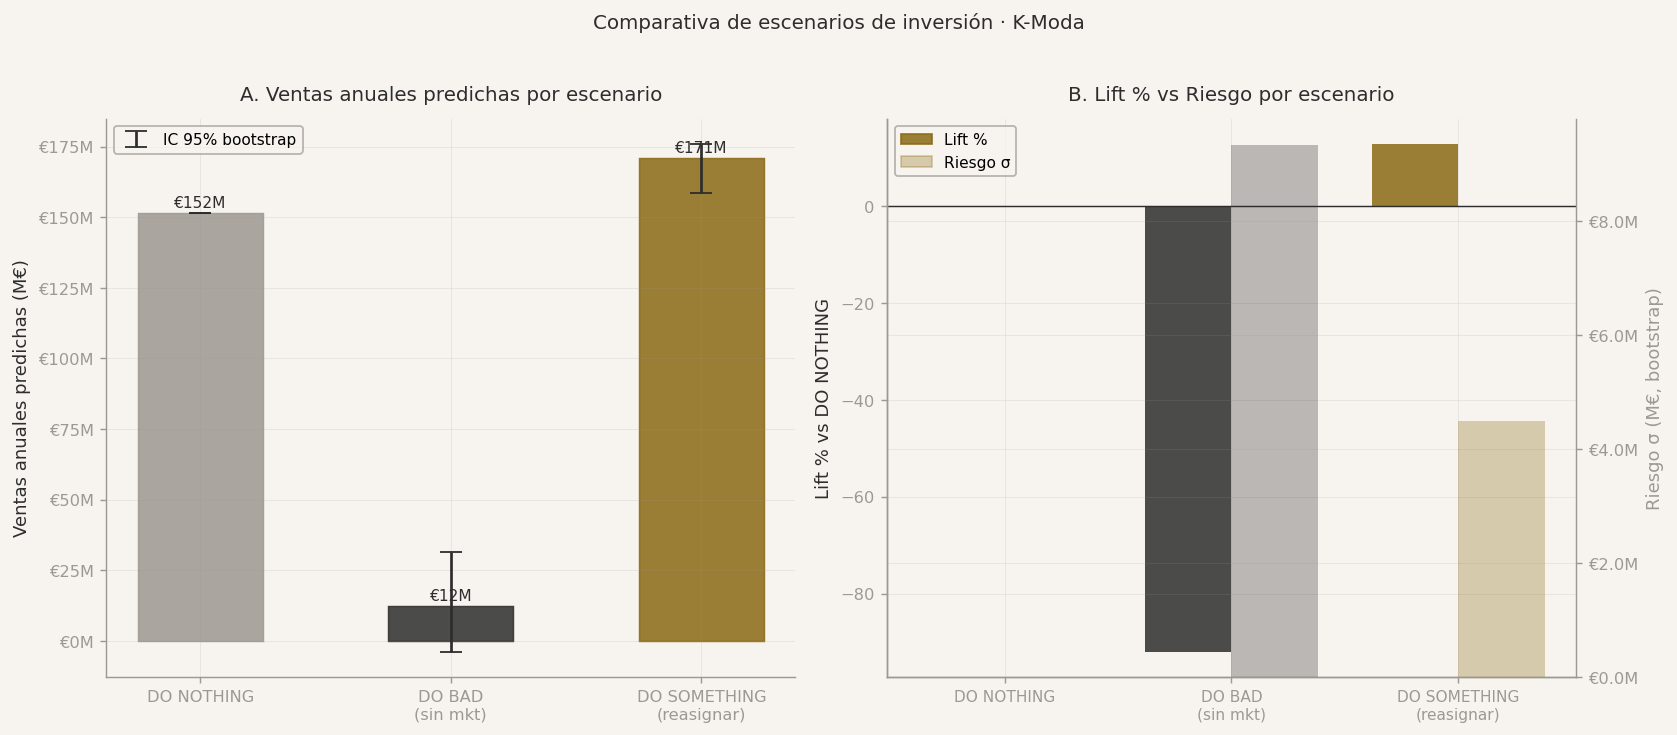

In [12]:
# ── Gráfico 4: Comparativa de escenarios ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Comparativa de escenarios de inversión · K-Moda', fontsize=11, color=KM_CHARCOAL, y=1.02)

eur = mticker.FuncFormatter(lambda x, _: f"€{x:.0f}M")

escenarios  = ['DO NOTHING', 'DO BAD\n(sin mkt)', 'DO SOMETHING\n(reasignar)']
ventas_m    = [r / 1e6 for r in [r_nothing['ventas_anual_idx'], r_bad['ventas_anual_idx'], r_something['ventas_anual_idx']]]
lift_vals   = [r_nothing['lift_pct'], r_bad['lift_pct'], r_something['lift_pct']]
sigma_m     = [r['lift_ic_std'] / 1e6 for r in [r_nothing, r_bad, r_something]]
ic_lo_m     = [r['lift_ic_lo']  / 1e6 for r in [r_nothing, r_bad, r_something]]
ic_hi_m     = [r['lift_ic_hi']  / 1e6 for r in [r_nothing, r_bad, r_something]]
bar_colors  = [KM_GRAY, KM_CHARCOAL, KM_GOLD_DARK]

# A: Ventas anuales con IC
ax = axes[0]
bars = ax.bar(escenarios, ventas_m, color=bar_colors, alpha=0.85, width=0.5,
              edgecolor=bar_colors, lw=0.8)
base_v = ventas_m[0] - r_nothing['lift_idx'] / 1e6
err_lo = [max(0, v - (base_v + lo)) for v, lo in zip(ventas_m, ic_lo_m)]
err_hi = [max(0, base_v + hi - v)   for v, hi in zip(ventas_m, ic_hi_m)]
ax.errorbar(escenarios, ventas_m, yerr=[err_lo, err_hi],
            fmt='none', color=KM_CHARCOAL, capsize=6, lw=1.5, label='IC 95% bootstrap')
for bar, val in zip(bars, ventas_m):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(err_hi) * 0.05,
            f'€{val:.0f}M', ha='center', va='bottom', fontsize=8.5, color=KM_CHARCOAL)
ax.yaxis.set_major_formatter(eur)
ax.set_ylabel('Ventas anuales predichas (M€)')
ax.set_title('A. Ventas anuales predichas por escenario')
ax.legend(fontsize=8.5)

# B: Lift % vs Riesgo σ
ax  = axes[1]
ax2 = ax.twinx()
x_pos, w = np.arange(len(escenarios)), 0.38
ax.bar(x_pos - w/2, lift_vals, width=w, color=bar_colors, alpha=0.85, label='Lift %')
ax2.bar(x_pos + w/2, sigma_m, width=w, color=bar_colors, alpha=0.3, label='Riesgo σ (M€)')
ax.axhline(0, color=KM_CHARCOAL, lw=0.8)
ax.set_xticks(x_pos); ax.set_xticklabels(escenarios, fontsize=8.5)
ax.set_ylabel('Lift % vs DO NOTHING', color=KM_CHARCOAL)
ax2.set_ylabel('Riesgo σ (M€, bootstrap)', color=KM_GRAY)
ax2.tick_params(axis='y', colors=KM_GRAY)
ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color(KM_GRAY)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.1f}M"))
ax.set_title('B. Lift % vs Riesgo por escenario')
p1 = mpatches.Patch(color=KM_GOLD_DARK, alpha=0.85, label='Lift %')
p2 = mpatches.Patch(color=KM_GOLD_DARK, alpha=0.30, label='Riesgo σ')
ax.legend(handles=[p1, p2], fontsize=8.5)

plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, 'ev_g4_escenarios.png'), dpi=150)
plt.show()

---
## 6. Análisis detallado del escenario DO SOMETHING

### Justificación de la reasignación

El escenario DO SOMETHING transfiere el **30% del presupuesto del bloque de menor ROI** al bloque de mayor ROI, manteniendo el presupuesto total constante.

**¿Dónde está el potencial de retorno?**
El bloque con mayor ROI tiene un coeficiente β más alto por euro invertido. Gracias a la transformación logadstock (saturación), el modelo captura los rendimientos decrecientes: a mayor inversión en un canal, la marginal de ventas que aporta cada euro adicional disminuye.

**¿Dónde está el riesgo?**
- La σ del lift sube porque concentramos presupuesto en un único bloque.
- Si el IC 95% del coeficiente de ese bloque es amplio, la incertidumbre se amplifica.
- Los rendimientos decrecientes (curva log) limitan cuánto se puede ganar con reasignación pura.

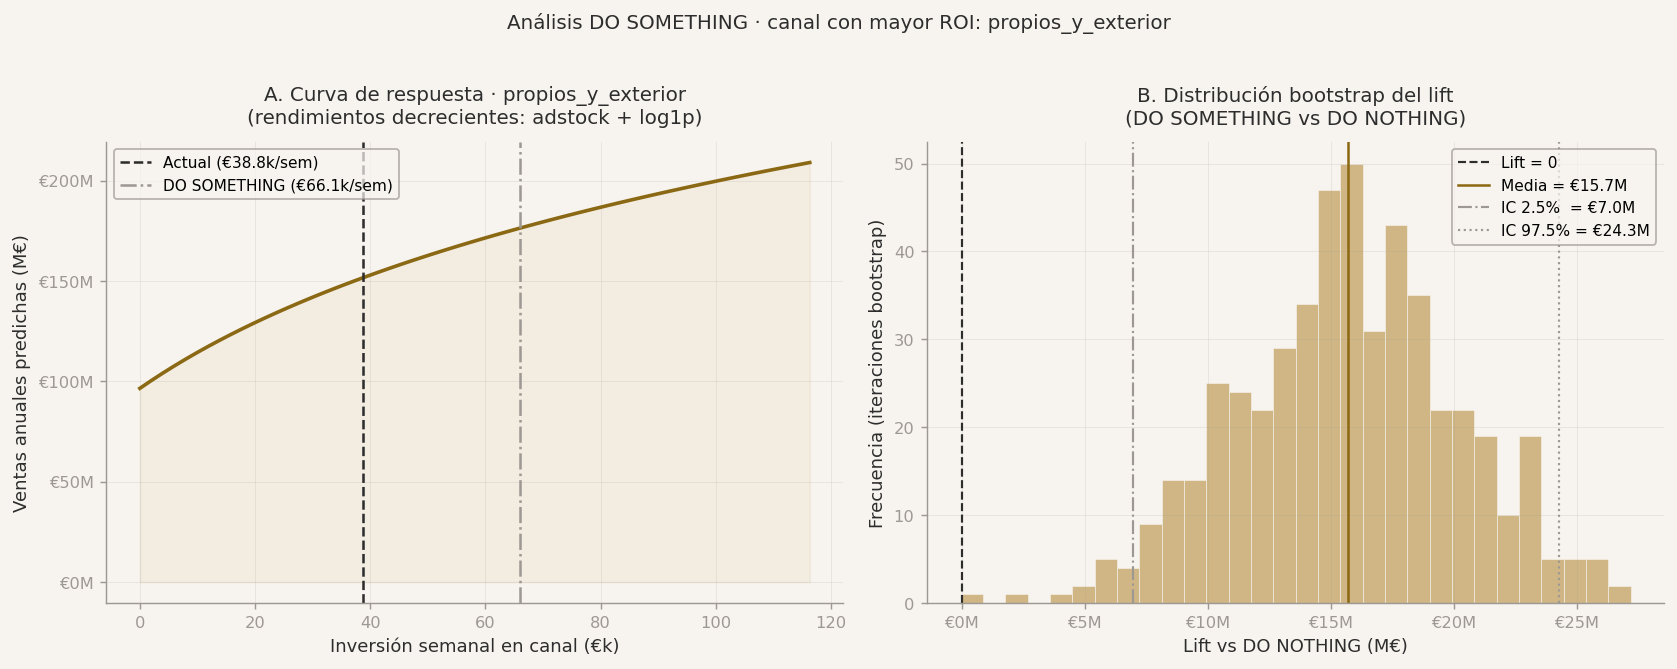

Probabilidad de lift positivo: 100%
IC 95%: [€7.0M, €24.3M]
Riesgo (σ): €4.5M


In [13]:
# ── Gráfico 5: Curva de respuesta + distribución bootstrap del lift ───────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Análisis DO SOMETHING · canal con mayor ROI: {canal_alto_roi}',
             fontsize=11, color=KM_CHARCOAL, y=1.02)

# A: Curva de respuesta
ax = axes[0]
inv_range    = np.linspace(0, inv_hist_media[inv_key_alto] * 3, 60)
ventas_curve = []
for inv_val in inv_range:
    inv_t = inv_hist_media.copy(); inv_t[inv_key_alto] = inv_val
    ventas_curve.append(simular(inv_t)['ventas_anual_idx'] / 1e6)
ventas_curve = np.array(ventas_curve)

ax.fill_between(inv_range / 1e3, ventas_curve, alpha=0.10, color=KM_GOLD)
ax.plot(inv_range / 1e3, ventas_curve, color=KM_GOLD_DARK, lw=2)
ax.axvline(inv_hist_media[inv_key_alto] / 1e3, color=KM_CHARCOAL, lw=1.4, ls='--',
           label=f'Actual (€{inv_hist_media[inv_key_alto]/1e3:.1f}k/sem)')
ax.axvline(inv_do_something[inv_key_alto] / 1e3, color=KM_GRAY, lw=1.4, ls='-.',
           label=f'DO SOMETHING (€{inv_do_something[inv_key_alto]/1e3:.1f}k/sem)')
ax.set_xlabel('Inversión semanal en canal (€k)')
ax.set_ylabel('Ventas anuales predichas (M€)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.0f}M"))
ax.set_title(f'A. Curva de respuesta · {canal_alto_roi}\n(rendimientos decrecientes: adstock + log1p)')
ax.legend(fontsize=8.5)

# B: Bootstrap del lift DO SOMETHING (en M€)
ax = axes[1]
inv_hist_ref  = {g: df[g].mean() for g in INV_GROUP_COLS}
lifts_boot_ds = []
for coefs in boot_coefs:
    m_tmp = type(model)(alpha=model.alpha, l1_ratio=model.l1_ratio, max_iter=10000)
    m_tmp.coef_ = coefs; m_tmp.intercept_ = model.intercept_
    lifts_boot_ds.append(
        m_tmp.predict(_build_X_sim(inv_do_something, 52)).sum() -
        m_tmp.predict(_build_X_sim(inv_hist_ref,     52)).sum()
    )
lifts_boot_m = np.array(lifts_boot_ds) / 1e6  # convertir a M€

ax.hist(lifts_boot_m, bins=30, color=KM_GOLD, alpha=0.82, edgecolor=KM_CREAM, lw=0.4)
ax.axvline(0,                              color=KM_CHARCOAL, lw=1.2, ls='--', label='Lift = 0')
ax.axvline(lifts_boot_m.mean(),            color=KM_GOLD_DARK, lw=1.4,
           label=f'Media = €{lifts_boot_m.mean():.1f}M')
ax.axvline(np.percentile(lifts_boot_m,  2.5), color=KM_GRAY, lw=1.2, ls='-.',
           label=f'IC 2.5%  = €{np.percentile(lifts_boot_m, 2.5):.1f}M')
ax.axvline(np.percentile(lifts_boot_m, 97.5), color=KM_GRAY, lw=1.2, ls=':',
           label=f'IC 97.5% = €{np.percentile(lifts_boot_m, 97.5):.1f}M')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:.0f}M"))
ax.set_xlabel('Lift vs DO NOTHING (M€)')
ax.set_ylabel('Frecuencia (iteraciones bootstrap)')
ax.set_title('B. Distribución bootstrap del lift\n(DO SOMETHING vs DO NOTHING)')
ax.legend(fontsize=8.5)

p_positivo = (np.array(lifts_boot_ds) > 0).mean() * 100
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, 'ev_g5_curva_respuesta.png'), dpi=150)
plt.show()

print(f'Probabilidad de lift positivo: {p_positivo:.0f}%')
print(f'IC 95%: [€{np.percentile(lifts_boot_m,2.5):.1f}M, €{np.percentile(lifts_boot_m,97.5):.1f}M]')
print(f'Riesgo (σ): €{lifts_boot_m.std():.1f}M')

### Gráfica · Distribución de presupuesto: DO NOTHING vs. DO SOMETHING

Comparativa canal a canal del presupuesto anual entre el escenario histórico y la
reasignación óptima. Las flechas rojas indican canales que pierden inversión;
las doradas los que ganan.

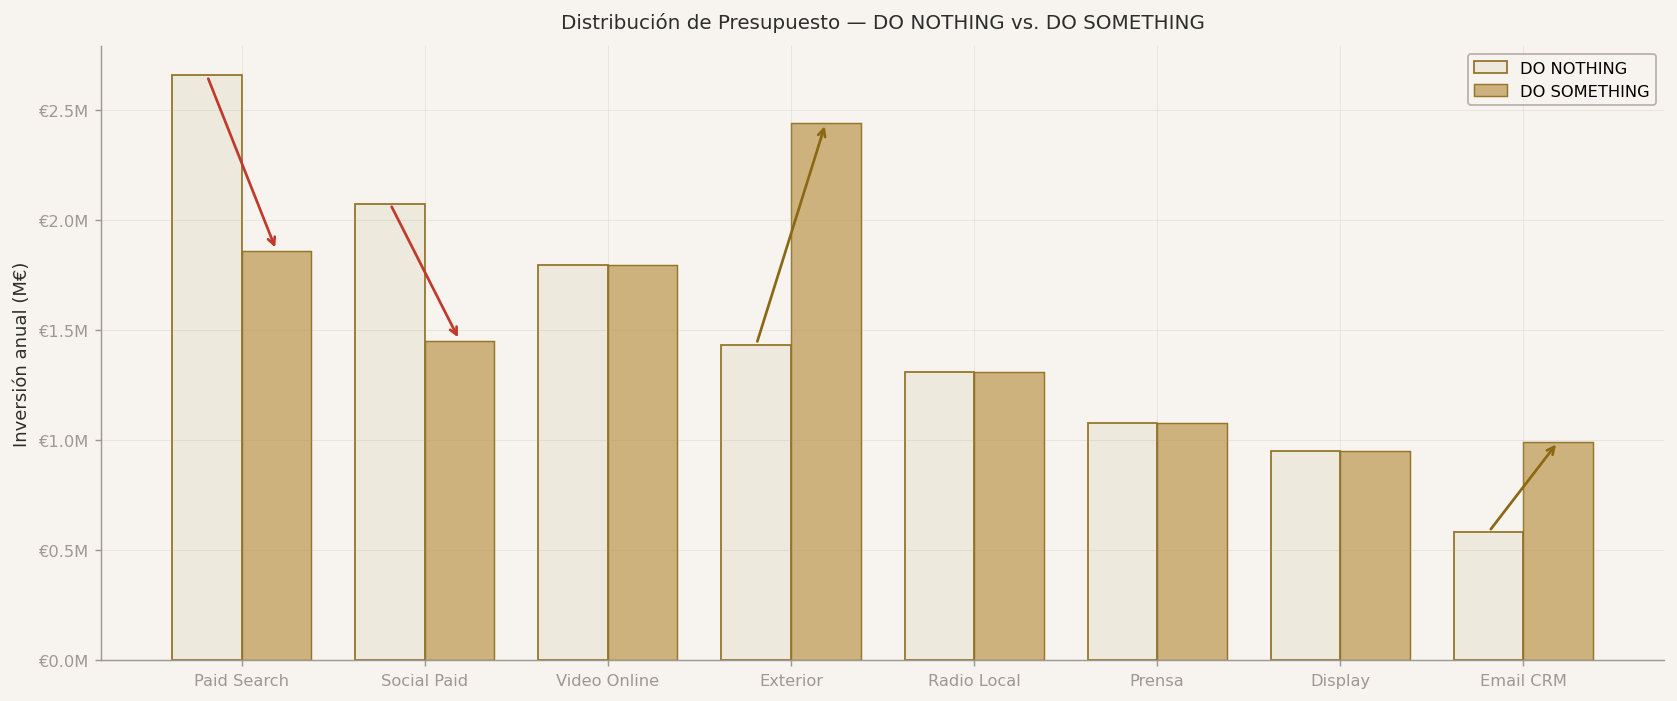

In [14]:
# ── Distribución de presupuesto DO NOTHING vs DO SOMETHING ───────────────────
CH_NAMES_8 = {"inv_paid_search":"Paid Search","inv_social_paid":"Social Paid",
               "inv_video_online":"Video Online","inv_display":"Display",
               "inv_email_crm":"Email CRM","inv_radio_local":"Radio Local",
               "inv_exterior":"Exterior","inv_prensa":"Prensa"}
INV_INDIV  = [c for cols in CHANNEL_GROUPS.values() for c in cols]

# Annual investment per individual channel
inv_dn_ind = {c: df[c].mean() * 52 for c in INV_INDIV}

# DO SOMETHING: distribute group changes proportionally within each group
inv_ds_groups = {f"inv_{g}": v * 52 for g, v in inv_do_something.items()
                 if f"inv_{g}" in [f"inv_{gg}" for gg in CHANNEL_GROUPS]}
inv_ds_groups.update({f"inv_{g}": inv_do_something[f"inv_{g}"] * 52
                      for g in CHANNEL_GROUPS if f"inv_{g}" in inv_do_something})

inv_ds_ind = {}
for g, cols in CHANNEL_GROUPS.items():
    group_hist = sum(inv_dn_ind[c] for c in cols)
    group_ds   = inv_do_something.get(f"inv_{g}", df[f"inv_{g}"].mean()) * 52
    for c in cols:
        prop = inv_dn_ind[c] / group_hist if group_hist > 0 else 1 / len(cols)
        inv_ds_ind[c] = group_ds * prop

# Sort by DO NOTHING descending
sorted_inv = sorted(INV_INDIV, key=lambda c: inv_dn_ind[c], reverse=True)
ch_labels  = [CH_NAMES_8[c] for c in sorted_inv]
x = np.arange(len(sorted_inv));  w = 0.38

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(x - w/2, [inv_dn_ind[c]/1e6 for c in sorted_inv], w,
       color=KM_IVORY, edgecolor=KM_GOLD_DARK, lw=1.0, alpha=0.9, label="DO NOTHING")
ax.bar(x + w/2, [inv_ds_ind[c]/1e6 for c in sorted_inv], w,
       color=KM_GOLD,  edgecolor=KM_GOLD_DARK, lw=0.8, alpha=0.88, label="DO SOMETHING")

for i, c in enumerate(sorted_inv):
    v_dn = inv_dn_ind[c] / 1e6
    v_ds = inv_ds_ind[c] / 1e6
    if abs(v_ds - v_dn) > 0.005:
        col_arrow = "#C0392B" if v_ds < v_dn else KM_GOLD_DARK
        ax.annotate("", xy=(x[i] + w/2, v_ds), xytext=(x[i] - w/2, v_dn),
                    arrowprops=dict(arrowstyle="->", color=col_arrow, lw=1.5))

ax.set_xticks(x); ax.set_xticklabels(ch_labels, fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"€{v:.1f}M"))
ax.set_ylabel("Inversión anual (M€)")
ax.set_title("Distribución de Presupuesto — DO NOTHING vs. DO SOMETHING")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "ev_g6_presupuesto.png"), dpi=150)
plt.show()

### Gráfica · Tornado — Sensibilidad de la contribución óptima a β (±20%)

Cuánto cambiaría la contribución total de marketing en el escenario DO SOMETHING
si el coeficiente β de cada canal fuera un 20% mayor o menor. Los canales con
mayor barra son los que más incertidumbre aportan al resultado.

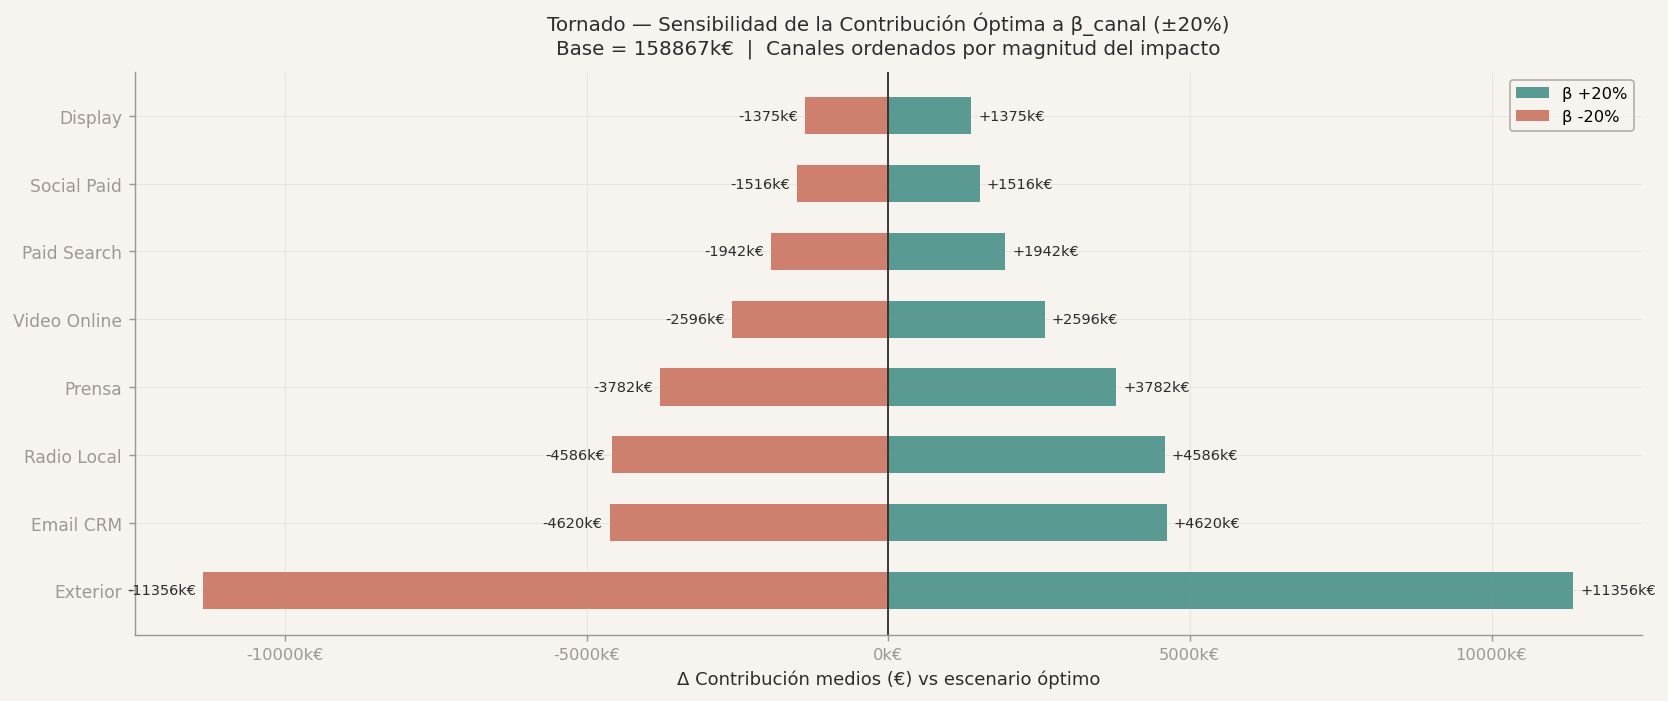

In [15]:
# ── Tornado: sensibilidad de la contribución óptima a β ±20% ─────────────────
# Contribución de cada grupo en el escenario DO SOMETHING
X_sim_ds = _build_X_sim(inv_do_something, 52)
contrib_ds = {}
for col in LOGADSTOCK_COLS:
    j = FEATURE_COLS.index(col)
    j_sc = COLS_TO_SCALE.index(col)
    beta_u = model.coef_[j] / scaler.scale_[j_sc]
    logads_raw = X_sim_ds[:, j] * scaler.scale_[j_sc] + scaler.mean_[j_sc]
    contrib_ds[col] = (beta_u * logads_raw).sum()

base_contrib = sum(contrib_ds.values())

# Map group contributions to individual channels (proportional split)
CH_NAMES_8 = {"inv_paid_search":"Paid Search","inv_social_paid":"Social Paid",
               "inv_video_online":"Video Online","inv_display":"Display",
               "inv_email_crm":"Email CRM","inv_radio_local":"Radio Local",
               "inv_exterior":"Exterior","inv_prensa":"Prensa"}
INV_INDIV = [c for cols in CHANNEL_GROUPS.values() for c in cols]
inv_hist_ind = {c: df[c].mean() * 52 for c in INV_INDIV}

delta_ind = {}
for g, cols in CHANNEL_GROUPS.items():
    logcol = f"logadstock_{g}"
    grp_contrib = contrib_ds.get(logcol, 0.0)
    group_hist  = sum(inv_hist_ind[c] for c in cols)
    for c in cols:
        prop = inv_hist_ind[c] / group_hist if group_hist > 0 else 1/len(cols)
        delta_ind[c] = 0.20 * grp_contrib * prop

# Sort by |Δ| descending
sorted_d = sorted(delta_ind.items(), key=lambda x: abs(x[1]), reverse=True)
labels_t = [CH_NAMES_8[c] for c, _ in sorted_d]
deltas_t = [d for _, d in sorted_d]

fig, ax = plt.subplots(figsize=(13, 5.5))
KM_TEAL = "#3D8B82";  KM_SALMON = "#C96B58"
for i, (label, d) in enumerate(zip(labels_t, deltas_t)):
    ax.barh(i,  d, color=KM_TEAL,   alpha=0.85, height=0.55, label="β +20%" if i==0 else "")
    ax.barh(i, -d, color=KM_SALMON, alpha=0.85, height=0.55, label="β -20%" if i==0 else "")
    ax.text( d + max(deltas_t)*0.01, i, f"+{d/1e3:.0f}k€", va="center", fontsize=8, color=KM_CHARCOAL)
    ax.text(-d - max(deltas_t)*0.01, i, f"-{d/1e3:.0f}k€", va="center", fontsize=8,
            color=KM_CHARCOAL, ha="right")

ax.set_yticks(range(len(labels_t))); ax.set_yticklabels(labels_t, fontsize=9.5)
ax.axvline(0, color=KM_CHARCOAL, lw=1.0)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k€"))
ax.set_xlabel("Δ Contribución medios (€) vs escenario óptimo")
ax.set_title(f"Tornado — Sensibilidad de la Contribución Óptima a β_canal (±20%)"
             f"\nBase = {base_contrib/1e3:.0f}k€  |  Canales ordenados por magnitud del impacto")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "ev_g7_tornado.png"), dpi=150)
plt.show()

### Gráfica · Heatmap de inversión: DO NOTHING vs. DO SOMETHING

Inversión normalizada (0–1) por canal para ambos escenarios. Permite ver de un vistazo
qué canales absorben más presupuesto y cómo cambia la distribución en la reasignación.

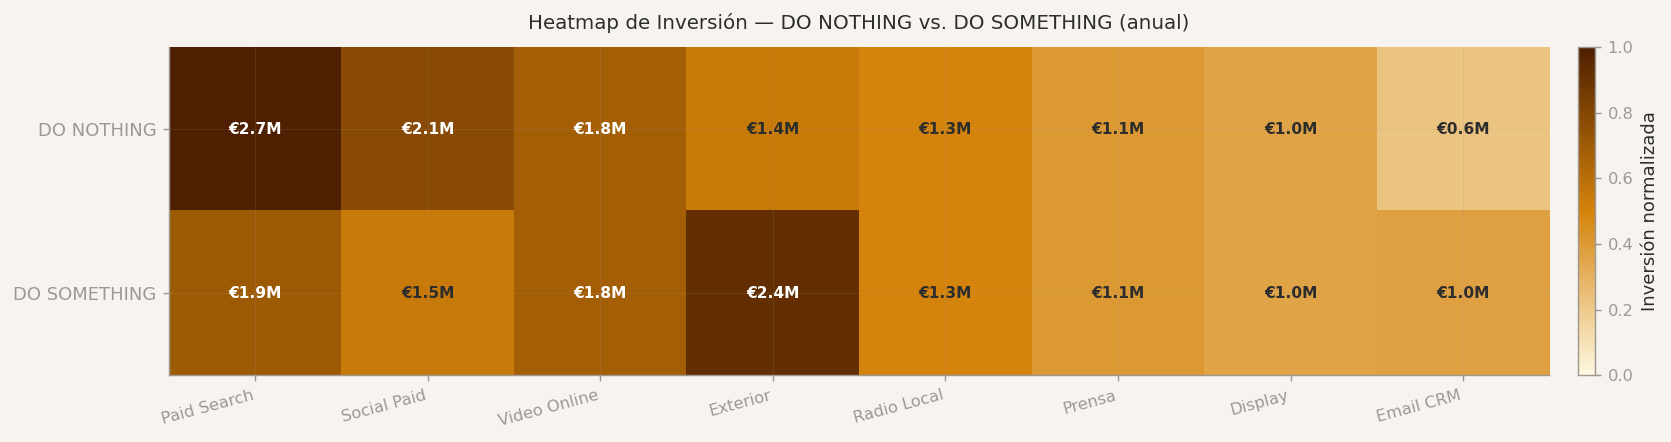

In [16]:
# ── Heatmap inversión DO NOTHING vs DO SOMETHING ────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

INV_INDIV = [c for cols in CHANNEL_GROUPS.values() for c in cols]
CH_NAMES_8 = {"inv_paid_search":"Paid Search","inv_social_paid":"Social Paid",
               "inv_video_online":"Video Online","inv_display":"Display",
               "inv_email_crm":"Email CRM","inv_radio_local":"Radio Local",
               "inv_exterior":"Exterior","inv_prensa":"Prensa"}
inv_dn_ind = {c: df[c].mean() * 52 for c in INV_INDIV}
inv_ds_ind = {}
for g, cols in CHANNEL_GROUPS.items():
    group_hist = sum(inv_dn_ind[c] for c in cols)
    group_ds   = inv_do_something.get(f"inv_{g}", df[f"inv_{g}"].mean()) * 52
    for c in cols:
        prop = inv_dn_ind[c] / group_hist if group_hist > 0 else 1/len(cols)
        inv_ds_ind[c] = group_ds * prop

# Sort by DO NOTHING descending
sorted_inv = sorted(INV_INDIV, key=lambda c: inv_dn_ind[c], reverse=True)
ch_labels  = [CH_NAMES_8[c] for c in sorted_inv]

matrix = np.array([
    [inv_dn_ind[c] for c in sorted_inv],
    [inv_ds_ind[c] for c in sorted_inv],
]) / 1e6

mat_norm = matrix / matrix.max()  # normalize 0-1

cmap_h = LinearSegmentedColormap.from_list("km_h", ["#FFF8E1", "#D4830A", "#4E1F00"])
fig, ax = plt.subplots(figsize=(13, 3.5))
im = ax.imshow(mat_norm, cmap=cmap_h, aspect="auto", vmin=0, vmax=1, interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Inversión normalizada")
ax.set_xticks(range(len(sorted_inv))); ax.set_xticklabels(ch_labels, fontsize=9, rotation=15, ha="right")
ax.set_yticks([0, 1]); ax.set_yticklabels(["DO NOTHING", "DO SOMETHING"], fontsize=10)
ax.set_title("Heatmap de Inversión — DO NOTHING vs. DO SOMETHING (anual)")
for row in range(2):
    for col, c in enumerate(sorted_inv):
        v  = matrix[row, col]
        tc = "white" if mat_norm[row, col] > 0.55 else KM_CHARCOAL
        ax.text(col, row, f"€{v:.1f}M", ha="center", va="center", fontsize=8.5,
                color=tc, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(WAREHOUSE, "ev_g8_heatmap_inversion.png"), dpi=150)
plt.show()

---
## 7. Resumen ejecutivo

### ¿Qué atribuye el modelo al marketing?

In [17]:
# ── Resumen ejecutivo ─────────────────────────────────────────────────────────
print('╔' + '═' * 68 + '╗')
print('║  RESUMEN EJECUTIVO · K-Moda MMM' + ' ' * 35 + '║')
print('╠' + '═' * 68 + '╣')
print(f'║  Período analizado:       2020–2024 ({len(df)} semanas)' + ' ' * 16 + '║')
print(f'║  Ventas totales reales:   €{total_ventas_eur/1e6:.1f}M' + ' ' * 37 + '║')
print('╠' + '═' * 68 + '╣')
print('║  CALIDAD DEL MODELO' + ' ' * 48 + '║')
print(f'║    R² test:  {test_r2:.3f}   MAPE test: {test_mape:.1f}%   [{verdict.split("·")[0].strip()}]' + ' ' * 2 + '║')
print(f'║    ΔR² placebo: {delta_r2:+.4f}  → señal de medios verificada' + ' ' * 11 + '║')
print('╠' + '═' * 68 + '╣')
print('║  ATRIBUCIÓN DE VENTAS' + ' ' * 46 + '║')
print(f'║    Base orgánica:  {frac_base*100:.1f}% (€{base_eur_total/1e6:.1f}M)' + ' ' * 36 + '║')
print(f'║    Marketing:      {frac_mkt*100:.1f}% (€{contrib_eur_total/1e6:.1f}M)' + ' ' * 36 + '║')
for col in LOGADSTOCK_COLS:
    nombre = col.replace('logadstock_', '')
    frac_c = contribs[col].sum() / total_pred_idx
    inv_c  = df[CHANNEL_GROUPS[nombre]].sum().sum() if nombre in CHANNEL_GROUPS else 0
    print(f'║      · {nombre:<12}: {frac_c*100:.1f}%  ROI={roi_por_canal[nombre]:.2f}x' + ' ' * 34 + '║')
print('╠' + '═' * 68 + '╣')
print('║  ESCENARIOS DE INVERSIÓN (52 semanas, ventas en Yt_indexed)' + ' ' * 8 + '║')
print(f'║    DO NOTHING:          {r_nothing["ventas_anual_idx"]:.4f}  (σ={r_nothing["lift_ic_std"]:.4f})' + ' ' * 15 + '║')
print(f'║    DO SOMETHING (BAD):  {r_bad["ventas_anual_idx"]:.4f}  (Δ={r_bad["lift_pct"]:+.1f}%)' + ' ' * 15 + '║')
print(f'║    DO SOMETHING:        {r_something["ventas_anual_idx"]:.4f}  (Δ={r_something["lift_pct"]:+.1f}%, σ={r_something["lift_ic_std"]:.4f})' + ' ' * 5 + '║')
print('╠' + '═' * 68 + '╣')
print(f'║  Canal recomendado para reasignación: {canal_alto_roi} (ROI={roi_por_canal[canal_alto_roi]:.2f}x)' + ' ' * 10 + '║')
print(f'║  P(lift positivo con DO SOMETHING): {p_positivo:.0f}%' + ' ' * 26 + '║')
print('╚' + '═' * 68 + '╝')

╔════════════════════════════════════════════════════════════════════╗
║  RESUMEN EJECUTIVO · K-Moda MMM                                   ║
╠════════════════════════════════════════════════════════════════════╣
║  Período analizado:       2020–2024 (258 semanas)                ║
║  Ventas totales reales:   €758.1M                                     ║
╠════════════════════════════════════════════════════════════════════╣
║  CALIDAD DEL MODELO                                                ║
║    R² test:  0.649   MAPE test: 12.2%   [✓ MAPE en rango válido (12.2% ∈ [8%, 20%])]  ║
║    ΔR² placebo: +0.5350  → señal de medios verificada           ║
╠════════════════════════════════════════════════════════════════════╣
║  ATRIBUCIÓN DE VENTAS                                              ║
║    Base orgánica:  8.0% (€60.4M)                                    ║
║    Marketing:      92.0% (€697.7M)                                    ║
║      · performance : 14.6%  ROI=4.71x                  